
FEATURE SELECTION FREQUENCY

                                 Selection_Count
Test Today - peak HR                          20
Risk Factor - ECHO - EF                       19
Age                                           18
Exercise Habit - Duration                     18
Risk Factor - Exercise                        17
Gait                                          17
Risk Level                                    17
Weekly_Exercise_Duration                      17
Target HR (bpm)                               15
Year                                          15
Risk Factor - Stress                          15
Test Today - Termination Cause                14
Exercise Habit - Frequency                    14
Occupation                                    14
Test Today - METS                             13
RISK - Risk Type                              13
Exercise Habit - Mode                         13
ECG Resting                                   12
Cooling Down                           

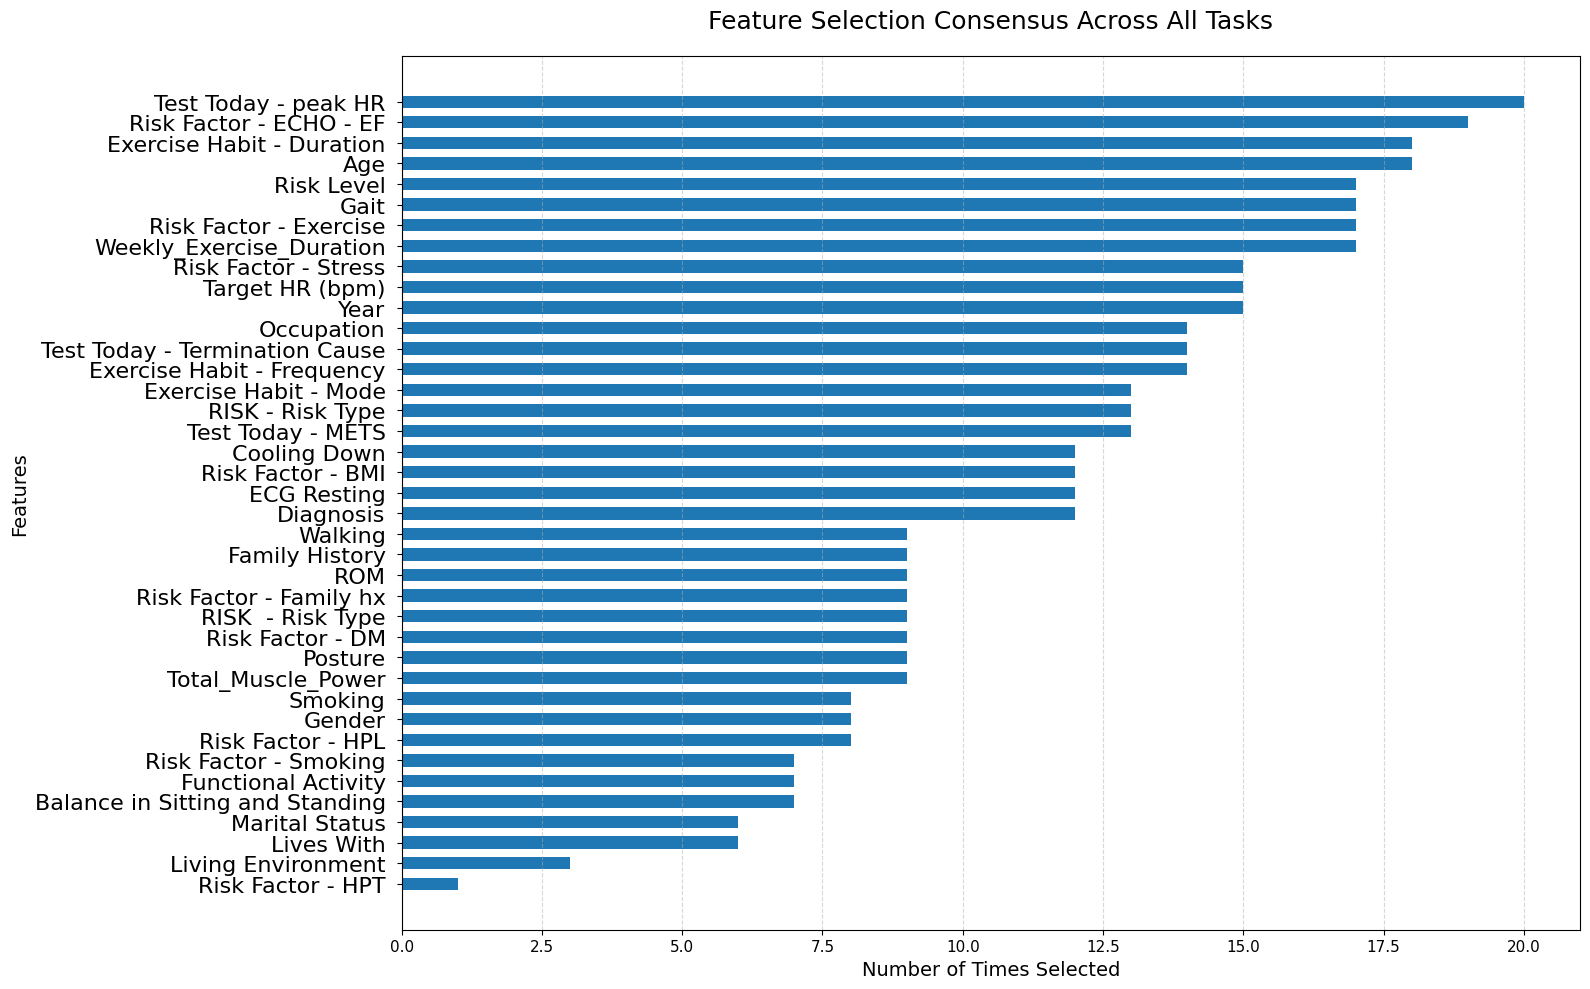


FILES SAVED SUCCESSFULLY


In [1]:
# COMPLETE FEATURE CONSENSUS ANALYSIS
# ALL 5 TASKS INCLUDED:
# 1. Risk Stratification
# 2. FITT - Frequency
# 3. FITT - Intensity (I)
# 4. FITT - Time (T1)
# 5. FITT - Type (T2)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# STORE ALL FEATURE SELECTION RESULTS

results = {

# ============================================================
# 1. RISK STRATIFICATION
# ============================================================

"Risk_ANOVA": [
'RISK  - Risk Type',
'Target HR (bpm)',
'Test Today - METS',
'Functional Activity',
'Risk Factor - ECHO - EF',
'Age',
'Smoking',
'Family History',
'Risk Factor - Family hx',
'Gait',
'Exercise Habit - Duration',
'Occupation',
'Balance in Sitting and Standing',
'Test Today - Termination Cause',
'Exercise Habit - Frequency'
],

"Risk_MI": [
'RISK  - Risk Type',
'Target HR (bpm)',
'Risk Factor - ECHO - EF',
'ECG Resting',
'Test Today - peak HR',
'Risk Factor - Exercise',
'Total_Muscle_Power',
'Test Today - Termination Cause',
'Family History',
'Gender',
'Year',
'Cooling Down',
'Test Today - METS',
'Gait',
'Exercise Habit - Mode'
],

"Risk_RFE_LR": [
'RISK  - Risk Type',
'Exercise Habit - Frequency',
'Exercise Habit - Mode',
'Walking',
'Diagnosis',
'Gait',
'Risk Factor - DM',
'Total_Muscle_Power',
'Smoking',
'Functional Activity',
'Posture',
'ROM',
'Test Today - METS',
'Marital Status',
'Risk Factor - ECHO - EF'
],

"Risk_RFE_SVM": [
'RISK  - Risk Type',
'Gait',
'Functional Activity',
'Walking',
'Total_Muscle_Power',
'Posture',
'Diagnosis',
'Risk Factor - DM',
'Test Today - METS',
'Risk Factor - Family hx',
'Target HR (bpm)',
'Age',
'Gender',
'Family History',
'Weekly_Exercise_Duration'
],

"Risk_LASSO": [
'RISK  - Risk Type',
'Posture',
'Diagnosis',
'Test Today - METS',
'Total_Muscle_Power',
'Risk Factor - Family hx',
'Gait',
'Age',
'Risk Factor - DM',
'Functional Activity',
'Smoking',
'Walking',
'Target HR (bpm)',
'Exercise Habit - Frequency',
'Risk Factor - Stress'
],

"Risk_RF": [
'RISK  - Risk Type',
'Target HR (bpm)',
'Risk Factor - ECHO - EF',
'Age',
'Weekly_Exercise_Duration',
'Exercise Habit - Duration',
'Exercise Habit - Frequency',
'Test Today - METS',
'ECG Resting',
'Risk Factor - BMI',
'Smoking',
'Test Today - Termination Cause',
'Diagnosis',
'Occupation',
'Exercise Habit - Mode'
],

# ============================================================
# 2. FITT - FREQUENCY (F)
# ============================================================

"F_ANOVA": [
'Weekly_Exercise_Duration',
'Risk Factor - Exercise',
'Year',
'Cooling Down',
'Balance in Sitting and Standing',
'Walking',
'Risk Factor - Smoking',
'Exercise Habit - Duration',
'Occupation',
'Risk Level',
'Gait',
'Risk Factor - ECHO - EF',
'Test Today - peak HR',
'Age',
'Family History'
],

"F_MI": [
'Weekly_Exercise_Duration',
'Risk Factor - Exercise',
'Risk Level',
'Gait',
'Cooling Down',
'Exercise Habit - Mode',
'Marital Status',
'Test Today - peak HR',
'Risk Factor - Stress',
'Test Today - Termination Cause',
'Exercise Habit - Duration',
'Walking',
'Lives With',
'Functional Activity',
'Smoking'
],

"F_RFE_LR": [
'Exercise Habit - Duration',
'Weekly_Exercise_Duration',
'Risk Level',
'RISK  - Risk Type',
'Year',
'Gait',
'Risk Factor - Exercise',
'Posture',
'Risk Factor - DM',
'Balance in Sitting and Standing',
'Risk Factor - Smoking',
'Test Today - peak HR',
'Target HR (bpm)',
'Family History',
'Occupation'
],

"F_RFE_SVM": [
'Exercise Habit - Duration',
'Weekly_Exercise_Duration',
'Risk Level',
'RISK  - Risk Type',
'Target HR (bpm)',
'Test Today - peak HR',
'Risk Factor - Smoking',
'Year',
'Risk Factor - Exercise',
'ECG Resting',
'Risk Factor - Family hx',
'Gait',
'Family History',
'Balance in Sitting and Standing',
'Risk Factor - DM'
],

"F_LASSO": [
'Exercise Habit - Duration',
'Weekly_Exercise_Duration',
'Risk Level',
'RISK  - Risk Type',
'Year',
'Risk Factor - Smoking',
'Risk Factor - Exercise',
'Family History',
'Test Today - peak HR',
'Gait',
'Cooling Down',
'Marital Status',
'ECG Resting',
'Risk Factor - HPL',
'Risk Factor - BMI'
],

"F_RF": [
'Weekly_Exercise_Duration',
'Exercise Habit - Duration',
'Target HR (bpm)',
'Age',
'Risk Factor - BMI',
'ECG Resting',
'Year',
'Risk Factor - ECHO - EF',
'Test Today - Termination Cause',
'Risk Factor - Exercise',
'Risk Level',
'Occupation',
'Diagnosis',
'Exercise Habit - Mode',
'Test Today - peak HR'
],

# ============================================================
# 3. FITT - INTENSITY (I)
# ============================================================

"I_ANOVA": [
'Test Today - peak HR',
'Age',
'RISK - Risk Type',
'Risk Level',
'Test Today - Termination Cause',
'Test Today - METS',
'Exercise Habit - Mode',
'Occupation',
'Risk Factor - Stress',
'Exercise Habit - Duration',
'Risk Factor - ECHO - EF',
'Diagnosis',
'ROM',
'ECG Resting',
'Risk Factor - DM'
],

"I_MI": [
'Test Today - peak HR',
'Test Today - METS',
'Functional Activity',
'Age',
'RISK - Risk Type',
'Living Environment',
'ROM',
'Risk Factor - Smoking',
'Risk Level',
'Weekly_Exercise_Duration',
'Walking',
'Gait',
'Risk Factor - Stress',
'Posture',
'Lives With'
],

"I_RFE_LR": [
'Age',
'Test Today - peak HR',
'Risk Level',
'RISK - Risk Type',
'Risk Factor - Stress',
'Gender',
'Risk Factor - DM',
'Test Today - Termination Cause',
'Risk Factor - Family hx',
'Risk Factor - HPL',
'Cooling Down',
'ECG Resting',
'Test Today - METS',
'Diagnosis',
'Exercise Habit - Duration'
],

"I_RFE_SVM": [
'Risk Level',
'RISK - Risk Type',
'Test Today - peak HR',
'Age',
'Exercise Habit - Duration',
'Gender',
'Risk Factor - Stress',
'Risk Factor - DM',
'Occupation',
'Risk Factor - Smoking',
'Smoking',
'Risk Factor - ECHO - EF',
'Marital Status',
'Gait',
'Test Today - METS'
],

"I_LASSO": [
'Age',
'Test Today - peak HR',
'Risk Factor - DM',
'Risk Factor - ECHO - EF',
'Exercise Habit - Duration',
'RISK - Risk Type',
'Gender',
'Occupation',
'Risk Factor - BMI',
'Gait',
'Test Today - Termination Cause',
'Risk Factor - Stress',
'Diagnosis',
'Exercise Habit - Mode',
'Walking'
],

"I_RF": [
'Age',
'Test Today - peak HR',
'Exercise Habit - Duration',
'Weekly_Exercise_Duration',
'Test Today - Termination Cause',
'Risk Factor - ECHO - EF',
'Exercise Habit - Frequency',
'Risk Factor - BMI',
'RISK - Risk Type',
'ECG Resting',
'Risk Level',
'Occupation',
'Diagnosis',
'Exercise Habit - Mode',
'Year'
],

# ============================================================
# 4. FITT - TIME (T1)
# ============================================================

"T1_ANOVA": [
'Weekly_Exercise_Duration',
'Risk Factor - ECHO - EF',
'Risk Factor - Stress',
'Risk Factor - HPL',
'Risk Factor - Exercise',
'Occupation',
'Total_Muscle_Power',
'Risk Level',
'Year',
'Posture',
'Exercise Habit - Mode',
'Balance in Sitting and Standing',
'Walking',
'RISK - Risk Type',
'ECG Resting'
],

"T1_MI": [
'Weekly_Exercise_Duration',
'Risk Factor - Stress',
'Risk Factor - ECHO - EF',
'Risk Factor - BMI',
'Test Today - METS',
'Risk Factor - Exercise',
'Risk Factor - Family hx',
'Cooling Down',
'Total_Muscle_Power',
'ROM',
'Functional Activity',
'Living Environment',
'Year',
'Gender',
'RISK - Risk Type'
],

"T1_RFE_LR": [
'Weekly_Exercise_Duration',
'Exercise Habit - Frequency',
'Posture',
'Lives With',
'Risk Factor - HPL',
'Occupation',
'Risk Factor - ECHO - EF',
'Risk Factor - Stress',
'Smoking',
'Risk Factor - Exercise',
'Test Today - METS',
'Exercise Habit - Mode',
'Gait',
'Balance in Sitting and Standing',
'Target HR (bpm)'
],

"T1_RFE_SVM": [
'Weekly_Exercise_Duration',
'Exercise Habit - Frequency',
'Posture',
'Exercise Habit - Mode',
'Test Today - Termination Cause',
'Risk Factor - HPL',
'Total_Muscle_Power',
'Gender',
'Lives With',
'Cooling Down',
'Marital Status',
'Target HR (bpm)',
'Risk Level',
'Test Today - peak HR',
'Risk Factor - Stress'
],

"T1_LASSO": [
'Weekly_Exercise_Duration',
'Exercise Habit - Frequency',
'Exercise Habit - Mode',
'Posture',
'Target HR (bpm)',
'Lives With',
'Risk Factor - HPL',
'Gender',
'Test Today - Termination Cause',
'Risk Factor - Stress',
'Marital Status',
'Total_Muscle_Power',
'Risk Factor - Exercise',
'Cooling Down',
'Risk Level'
],

"T1_RF": [
'Weekly_Exercise_Duration',
'Target HR (bpm)',
'Risk Factor - ECHO - EF',
'Age',
'Exercise Habit - Frequency',
'Exercise Habit - Mode',
'Risk Factor - BMI',
'Risk Factor - Exercise',
'Year',
'Test Today - Termination Cause',
'ECG Resting',
'Occupation',
'Diagnosis',
'Risk Factor - HPL',
'Smoking'
],

# ============================================================
# 5. FITT - TYPE (T2)
# ============================================================

"T2_ANOVA": [
'ROM',
'Age',
'Risk Factor - BMI',
'Target HR (bpm)',
'Year',
'Gait',
'Exercise Habit - Duration',
'RISK - Risk Type',
'Exercise Habit - Frequency',
'Occupation',
'Lives With',
'Test Today - peak HR',
'Risk Factor - Exercise',
'Test Today - Termination Cause',
'Family History'
],

"T2_MI": [
'Total_Muscle_Power',
'Walking',
'Gait',
'Living Environment',
'ROM',
'Diagnosis',
'Balance in Sitting and Standing',
'Family History',
'Test Today - peak HR',
'RISK - Risk Type',
'ECG Resting',
'Risk Factor - ECHO - EF',
'Cooling Down',
'Risk Factor - Stress',
'Risk Factor - Smoking'
],

"T2_RFE_LR": [
'Exercise Habit - Duration',
'Age',
'Risk Factor - BMI',
'Test Today - peak HR',
'Risk Factor - ECHO - EF',
'Risk Factor - Family hx',
'RISK - Risk Type',
'Risk Level',
'Year',
'Cooling Down',
'ROM',
'Risk Factor - Exercise',
'Exercise Habit - Frequency',
'Risk Factor - HPT',
'Test Today - METS'
],

"T2_RFE_SVM": [
'Exercise Habit - Duration',
'RISK - Risk Type',
'Risk Level',
'Year',
'Risk Factor - Family hx',
'Age',
'Risk Factor - ECHO - EF',
'Risk Factor - BMI',
'Exercise Habit - Frequency',
'Risk Factor - Exercise',
'ROM',
'Cooling Down',
'Test Today - peak HR',
'Risk Factor - Stress',
'Risk Factor - HPL'
],

"T2_LASSO": [
'Year',
'Age',
'Cooling Down',
'Risk Factor - ECHO - EF',
'Risk Factor - Exercise',
'Exercise Habit - Duration',
'Exercise Habit - Frequency',
'Risk Factor - BMI',
'RISK - Risk Type',
'ROM',
'Test Today - peak HR',
'Target HR (bpm)',
'Gait',
'Risk Factor - Family hx',
'Risk Factor - Stress'
],

"T2_RF": [
'Age',
'Exercise Habit - Duration',
'Exercise Habit - Frequency',
'Weekly_Exercise_Duration',
'Target HR (bpm)',
'Risk Factor - BMI',
'Year',
'Risk Factor - ECHO - EF',
'ECG Resting',
'Test Today - Termination Cause',
'Risk Factor - Exercise',
'Diagnosis',
'Occupation',
'Risk Level',
'Test Today - peak HR'
]

}

# ============================================================
# FEATURE FREQUENCY ANALYSIS
# ============================================================

all_features = []

for method, features in results.items():
    all_features.extend(features)

feature_counts = Counter(all_features)

consensus_df = pd.DataFrame.from_dict(
    feature_counts,
    orient='index',
    columns=['Selection_Count']
)

consensus_df = consensus_df.sort_values(
    by='Selection_Count',
    ascending=False
)

# PRINT RESULTS

print("\n================================================")
print("FEATURE SELECTION FREQUENCY")
print("================================================\n")

print(consensus_df)

# ============================================================
# BAR CHART

# SORT FEATURES
plot_df = consensus_df.sort_values(
    by='Selection_Count',
    ascending=True
)

# ============================================================
# MANUAL SETTINGS (ADJUST HERE)
# ============================================================

FIG_WIDTH = 16 # <-- CHANGE FEATURE NAME SIZE HERE
FIG_HEIGHT = 10 # <-- CHANGE FEATURE NAME SIZE HERE

BAR_HEIGHT = 0.6 # <-- CHANGE FEATURE NAME SIZE HERE

TITLE_FONT = 18
AXIS_FONT = 14

FEATURE_FONT = 16      # <-- CHANGE FEATURE NAME SIZE HERE
X_TICK_FONT = 11

LEFT_MARGIN = 0.42     # <-- INCREASE if labels cut off

# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(FIG_WIDTH, FIG_HEIGHT)
)

# ============================================================
# BAR CHART
# ============================================================

ax.barh(
    plot_df.index,
    plot_df['Selection_Count'],
    height=BAR_HEIGHT
)

# ============================================================
# TITLES
# ============================================================

ax.set_title(
    "Feature Selection Consensus Across All Tasks",
    fontsize=TITLE_FONT,
    pad=20
)

ax.set_xlabel(
    "Number of Times Selected",
    fontsize=AXIS_FONT
)

ax.set_ylabel(
    "Features",
    fontsize=AXIS_FONT
)

# ============================================================
# FONT SIZE CONTROL
# ============================================================

# FEATURE NAMES
ax.tick_params(
    axis='y',
    labelsize=FEATURE_FONT,
    pad=8
)

# X-AXIS NUMBERS
ax.tick_params(
    axis='x',
    labelsize=X_TICK_FONT
)

# ============================================================
# EXTRA SPACING
# ============================================================

plt.subplots_adjust(left=LEFT_MARGIN)

# GRID
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

# FINAL LAYOUT
plt.tight_layout()

plt.show()

consensus_df.to_csv(
    "feature_consensus_analysis.csv"
)

print("\n================================================")
print("FILES SAVED SUCCESSFULLY")
print("================================================")

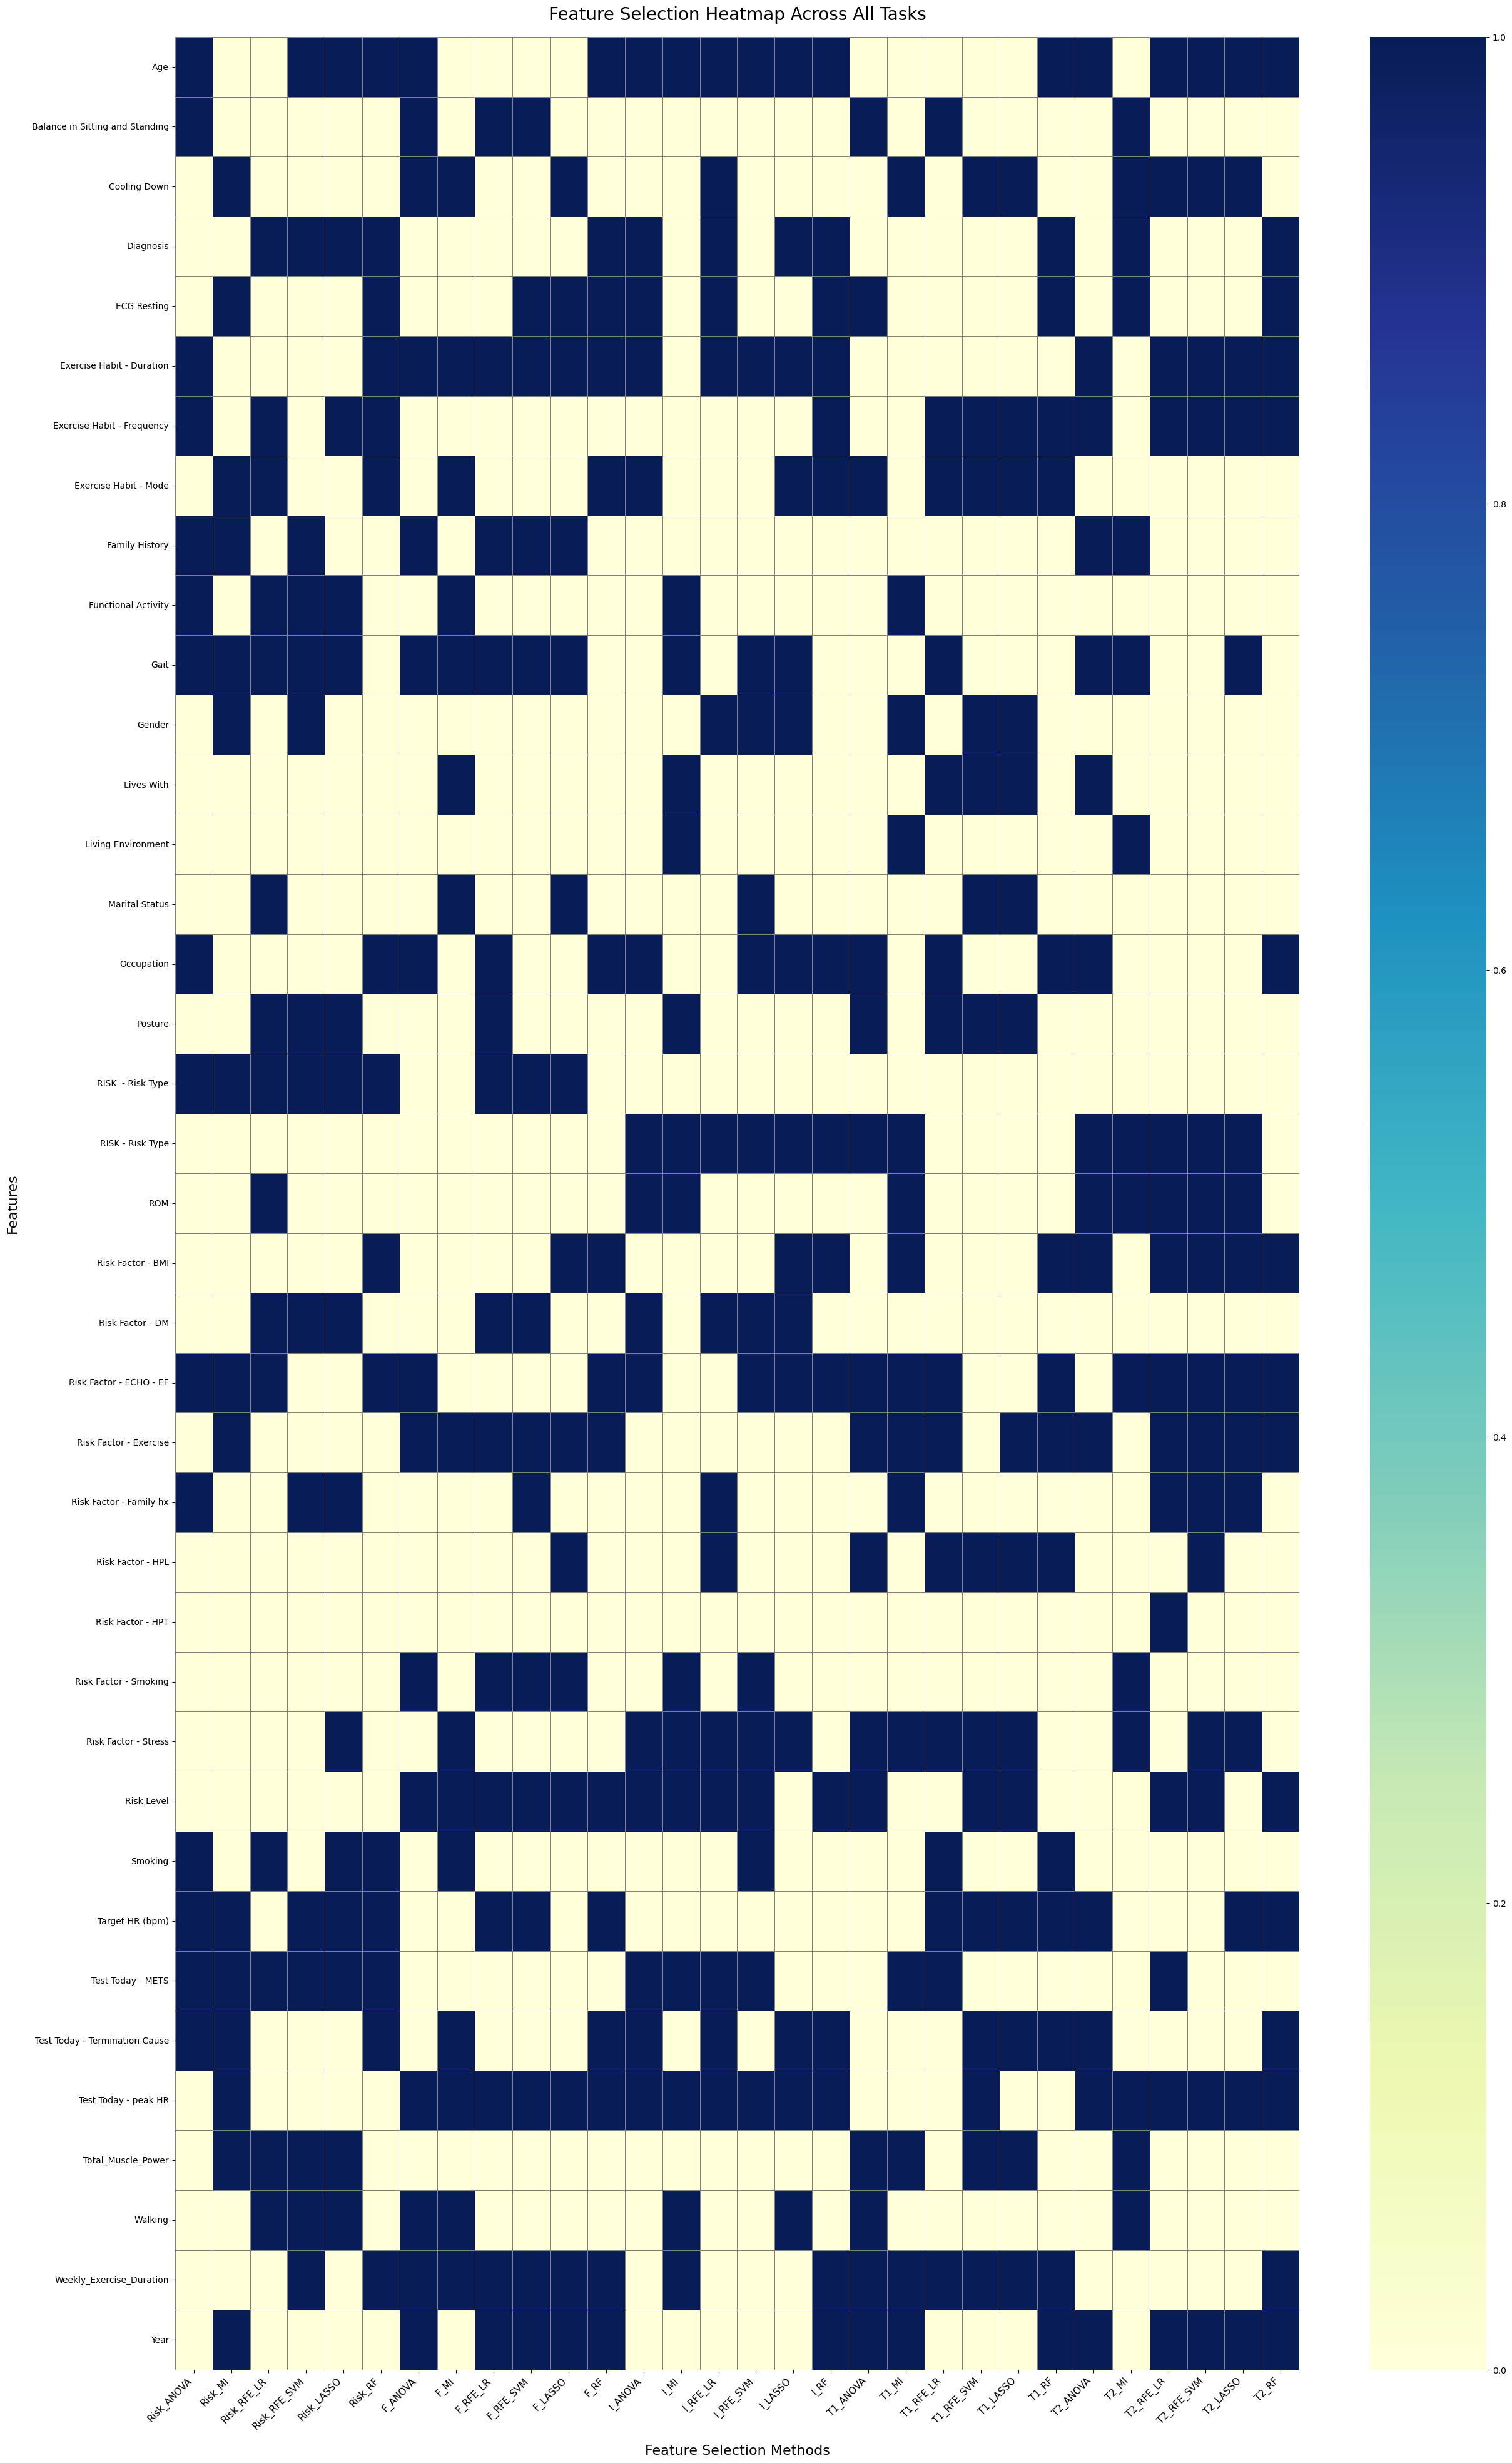


FEATURE CONSENSUS GROUPS

Selected by 20 methods (1 features):
['Test Today - peak HR']

Selected by 19 methods (1 features):
['Risk Factor - ECHO - EF']

Selected by 18 methods (2 features):
['Age', 'Exercise Habit - Duration']

Selected by 17 methods (4 features):
['Risk Factor - Exercise', 'Gait', 'Risk Level', 'Weekly_Exercise_Duration']

Selected by 15 methods (3 features):
['Target HR (bpm)', 'Year', 'Risk Factor - Stress']

Selected by 14 methods (3 features):
['Test Today - Termination Cause', 'Exercise Habit - Frequency', 'Occupation']

Selected by 13 methods (3 features):
['Test Today - METS', 'RISK - Risk Type', 'Exercise Habit - Mode']

Selected by 12 methods (4 features):
['ECG Resting', 'Cooling Down', 'Risk Factor - BMI', 'Diagnosis']

Selected by 9 methods (8 features):
['RISK  - Risk Type', 'Risk Factor - DM', 'Risk Factor - Family hx', 'ROM', 'Family History', 'Total_Muscle_Power', 'Posture', 'Walking']

Selected by 8 methods (3 features):
['Risk Factor - HPL', 'Smok

In [2]:
# HEATMAP
# CREATE FEATURE MATRIX
unique_features = sorted(set(all_features))

feature_matrix = pd.DataFrame({
    method: [
        1 if feature in feats else 0
        for feature in unique_features
    ]
    for method, feats in results.items()
}, index=unique_features)

# PLOT HEATMAP
plt.figure(figsize=(26, 40))   # increase height

sns.heatmap(
    feature_matrix,
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='gray',
    cbar=True
)

# TITLE AND LABELS
plt.title(
    "Feature Selection Heatmap Across All Tasks",
    fontsize=20,
    pad=20
)

plt.xlabel(
    "Feature Selection Methods",
    fontsize=16,
    labelpad=15
)

plt.ylabel(
    "Features",
    fontsize=16,
    labelpad=15
)

# ADJUST TICK LABEL SIZE
plt.xticks(
    rotation=45,
    ha='right',
    fontsize=11
)

plt.yticks(
    rotation=0,
    fontsize=10
)

# ADD MORE SPACE
plt.tight_layout(pad=3)

plt.show()

# ============================================================
# CONSENSUS GROUP ANALYSIS
# ============================================================

print("\n================================================")
print("FEATURE CONSENSUS GROUPS")
print("================================================")

max_methods = len(results)

for k in range(max_methods, 0, -1):

    selected = consensus_df[
        consensus_df['Selection_Count'] == k
    ].index.tolist()

    if len(selected) > 0:

        print(f"\nSelected by {k} methods "
              f"({len(selected)} features):")

        print(selected)

# ============================================================
# SAVE RESULTS
# ============================================================

feature_matrix.to_csv(
    "feature_selection_heatmap_matrix.csv"
)

print("\n================================================")
print("FILES SAVED SUCCESSFULLY")
print("================================================")